In [70]:
import pandas as pd

Task 1 – Data Exploration & Preprocessing

Load and inspect the dataset

In [71]:
df=pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/crowdfunding.csv")

In [72]:
df

,Unnamed: 0,CampaignID,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates,IsSuccessful
0,0,CID_00000,76159,73518.028955,15,1903,Film,September,Australia,GBP,11,Yes,41758,3,0
1,1,CID_00001,69394,60068.683288,49,469,Art,October,Australia,GBP,7,Yes,79112,48,0
2,2,CID_00002,18652,22958.153470,58,148,Film,February,USA,EUR,17,No,3942,9,1
3,3,CID_00003,19487,24229.048390,39,780,Film,October,Germany,AUD,10,No,22047,35,1
4,4,CID_00004,26734,17984.630311,68,1622,Games,September,Australia,AUD,12,Yes,72568,17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,CID_99995,80417,112068.932642,26,870,Music,October,UK,AUD,6,No,84173,8,1
99996,99996,CID_99996,85052,100430.502040,78,1146,Film,October,USA,USD,8,No,13913,42,1
99997,99997,CID_99997,68407,102020.936312,87,636,Art,March,UK,EUR,2,Yes,45273,13,1
99998,99998,CID_99998,59749,67026.111706,51,1276,Music,August,Australia,CAD,10,Yes,67574,29,1


In [73]:
df.columns

Index(['Unnamed: 0', 'CampaignID', 'GoalAmount', 'RaisedAmount',
       'DurationDays', 'NumBackers', 'Category', 'LaunchMonth', 'Country',
       'Currency', 'OwnerExperience', 'VideoIncluded', 'SocialMediaPresence',
       'NumUpdates', 'IsSuccessful'],
      dtype='str')

In [74]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [75]:
df.head()

,CampaignID,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates,IsSuccessful
0,CID_00000,76159,73518.028955,15,1903,Film,September,Australia,GBP,11,Yes,41758,3,0
1,CID_00001,69394,60068.683288,49,469,Art,October,Australia,GBP,7,Yes,79112,48,0
2,CID_00002,18652,22958.153470,58,148,Film,February,USA,EUR,17,No,3942,9,1
3,CID_00003,19487,24229.048390,39,780,Film,October,Germany,AUD,10,No,22047,35,1
4,CID_00004,26734,17984.630311,68,1622,Games,September,Australia,AUD,12,Yes,72568,17,0


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CampaignID           100000 non-null  str    
 1   GoalAmount           100000 non-null  int64  
 2   RaisedAmount         100000 non-null  float64
 3   DurationDays         100000 non-null  int64  
 4   NumBackers           100000 non-null  int64  
 5   Category             100000 non-null  str    
 6   LaunchMonth          100000 non-null  str    
 7   Country              100000 non-null  str    
 8   Currency             100000 non-null  str    
 9   OwnerExperience      100000 non-null  int64  
 10  VideoIncluded        100000 non-null  str    
 11  SocialMediaPresence  100000 non-null  int64  
 12  NumUpdates           100000 non-null  int64  
 13  IsSuccessful         100000 non-null  int64  
dtypes: float64(1), int64(7), str(6)
memory usage: 10.7 MB


Handle missing values and duplicates

In [77]:
df.isnull().sum()


CampaignID             0
GoalAmount             0
RaisedAmount           0
DurationDays           0
NumBackers             0
Category               0
LaunchMonth            0
Country                0
Currency               0
OwnerExperience        0
VideoIncluded          0
SocialMediaPresence    0
NumUpdates             0
IsSuccessful           0
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(0)

Encode categorical variables

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CampaignID           100000 non-null  str    
 1   GoalAmount           100000 non-null  int64  
 2   RaisedAmount         100000 non-null  float64
 3   DurationDays         100000 non-null  int64  
 4   NumBackers           100000 non-null  int64  
 5   Category             100000 non-null  str    
 6   LaunchMonth          100000 non-null  str    
 7   Country              100000 non-null  str    
 8   Currency             100000 non-null  str    
 9   OwnerExperience      100000 non-null  int64  
 10  VideoIncluded        100000 non-null  str    
 11  SocialMediaPresence  100000 non-null  int64  
 12  NumUpdates           100000 non-null  int64  
 13  IsSuccessful         100000 non-null  int64  
dtypes: float64(1), int64(7), str(6)
memory usage: 10.7 MB


In [80]:
categorical_cols=df.select_dtypes(include='str')

In [81]:
categorical_cols=categorical_cols.columns.to_list()

In [82]:
categorical_cols

['CampaignID',
 'Category',
 'LaunchMonth',
 'Country',
 'Currency',
 'VideoIncluded']

In [83]:
categorical_cols.remove('CampaignID')

In [84]:
categorical_cols

['Category', 'LaunchMonth', 'Country', 'Currency', 'VideoIncluded']

In [85]:
import numpy as np

In [86]:
numerical_cols=df.select_dtypes(include=np.number).columns.to_list()

In [87]:
numerical_cols

['GoalAmount',
 'RaisedAmount',
 'DurationDays',
 'NumBackers',
 'OwnerExperience',
 'SocialMediaPresence',
 'NumUpdates',
 'IsSuccessful']

In [88]:
from sklearn.preprocessing import LabelEncoder

In [89]:
labelencoders={}

In [90]:
for col in categorical_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    labelencoders[col]=dict(zip(le.classes_,le.transform(le.classes_)))

In [91]:
labelencoders

{'Category': {'Art': np.int64(0),
  'Film': np.int64(1),
  'Games': np.int64(2),
  'Music': np.int64(3),
  'Technology': np.int64(4)},
 'LaunchMonth': {'April': np.int64(0),
  'August': np.int64(1),
  'December': np.int64(2),
  'February': np.int64(3),
  'January': np.int64(4),
  'July': np.int64(5),
  'June': np.int64(6),
  'March': np.int64(7),
  'May': np.int64(8),
  'November': np.int64(9),
  'October': np.int64(10),
  'September': np.int64(11)},
 'Country': {'Australia': np.int64(0),
  'Canada': np.int64(1),
  'Germany': np.int64(2),
  'UK': np.int64(3),
  'USA': np.int64(4)},
 'Currency': {'AUD': np.int64(0),
  'CAD': np.int64(1),
  'EUR': np.int64(2),
  'GBP': np.int64(3),
  'USD': np.int64(4)},
 'VideoIncluded': {'No': np.int64(0), 'Yes': np.int64(1)}}

In [92]:
df=df.drop(columns=['CampaignID'])

In [93]:
df.columns

Index(['GoalAmount', 'RaisedAmount', 'DurationDays', 'NumBackers', 'Category',
       'LaunchMonth', 'Country', 'Currency', 'OwnerExperience',
       'VideoIncluded', 'SocialMediaPresence', 'NumUpdates', 'IsSuccessful'],
      dtype='str')

In [94]:
#encoded df
df.head()

,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates,IsSuccessful
0,76159,73518.028955,15,1903,1,11,0,3,11,1,41758,3,0
1,69394,60068.683288,49,469,0,10,0,3,7,1,79112,48,0
2,18652,22958.153470,58,148,1,3,4,2,17,0,3942,9,1
3,19487,24229.048390,39,780,1,10,2,0,10,0,22047,35,1
4,26734,17984.630311,68,1622,2,11,0,0,12,1,72568,17,0


Perform feature selection

In [95]:
df.corr()

,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates,IsSuccessful
GoalAmount,1.000000,0.863471,-0.003708,0.005366,0.002413,-0.002721,-0.003059,-0.000346,0.003173,-0.005065,-0.005022,-0.002585,0.004240
RaisedAmount,0.863471,1.000000,-0.003111,0.003375,0.004033,-0.003567,-0.003502,0.002479,-0.000004,-0.004859,-0.002970,-0.001606,0.384000
DurationDays,-0.003708,-0.003111,1.000000,-0.002663,0.005711,0.001686,-0.000696,0.000240,0.000883,0.002717,0.004913,-0.003346,0.002787
NumBackers,0.005366,0.003375,-0.002663,1.000000,0.001975,-0.001569,-0.000936,0.000707,-0.000273,-0.001224,-0.001548,-0.004977,-0.002590
Category,0.002413,0.004033,0.005711,0.001975,1.000000,-0.001699,-0.001531,0.001834,-0.004937,0.001597,0.001054,0.000564,0.001984
LaunchMonth,-0.002721,-0.003567,0.001686,-0.001569,-0.001699,1.000000,0.000395,0.001839,-0.000477,-0.001695,0.005149,0.010426,-0.001153
Country,-0.003059,-0.003502,-0.000696,-0.000936,-0.001531,0.000395,1.000000,-0.002053,0.001610,0.001174,0.002493,-0.002024,-0.001269
Currency,-0.000346,0.002479,0.000240,0.000707,0.001834,0.001839,-0.002053,1.000000,0.000591,-0.003786,-0.000427,-0.002253,0.003088
OwnerExperience,0.003173,-0.000004,0.000883,-0.000273,-0.004937,-0.000477,0.001610,0.000591,1.000000,0.002316,0.001623,-0.002813,-0.007015
VideoIncluded,-0.005065,-0.004859,0.002717,-0.001224,0.001597,-0.001695,0.001174,-0.003786,0.002316,1.000000,-0.004740,-0.001769,0.002807


In [96]:
import matplotlib.pyplot as plt

In [97]:
import seaborn as sns

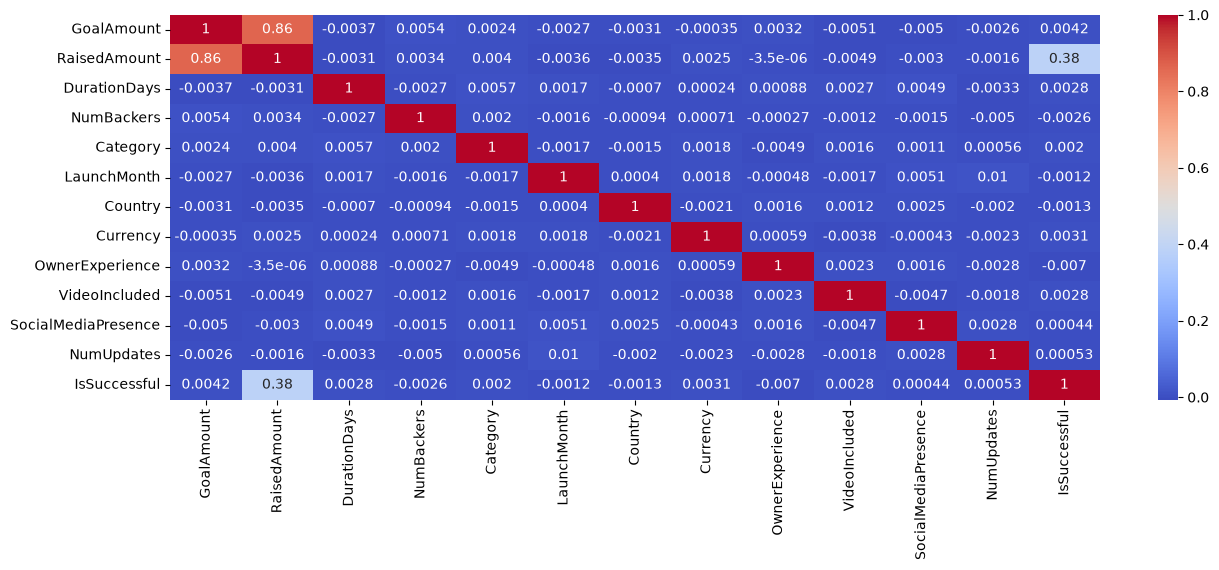

In [98]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [99]:
df.columns

Index(['GoalAmount', 'RaisedAmount', 'DurationDays', 'NumBackers', 'Category',
       'LaunchMonth', 'Country', 'Currency', 'OwnerExperience',
       'VideoIncluded', 'SocialMediaPresence', 'NumUpdates', 'IsSuccessful'],
      dtype='str')

In [100]:
x=df.drop(columns=['IsSuccessful'])

In [101]:
x.columns

Index(['GoalAmount', 'RaisedAmount', 'DurationDays', 'NumBackers', 'Category',
       'LaunchMonth', 'Country', 'Currency', 'OwnerExperience',
       'VideoIncluded', 'SocialMediaPresence', 'NumUpdates'],
      dtype='str')

In [102]:
y=df['IsSuccessful']

In [103]:
#from sklearn.feature_selection import SelectKBest
#from sklearn.feature_selection import f_classif

In [104]:
#selector=SelectKBest(score_func=f_classif,k=7)

In [105]:
#selector.fit_transform(x,y)

In [106]:
#selected_featues=x.columns[selector.get_support()]

In [107]:
#selected_featues

In [108]:
#feature_score=pd.DataFrame({'feature':x.columns, 'score': selector.scores_ }).sort_values(by='score',ascending=False)
#feature_score

In [109]:
#x_selected=x[selected_featues]

In [110]:
#type(x_selected)

Split the dataset into training and testing sets

In [111]:
from sklearn.model_selection import train_test_split

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


Apply feature scaling where required

In [113]:
from sklearn.preprocessing import StandardScaler

In [114]:
scaler=StandardScaler()

In [115]:
numerical_cols

['GoalAmount',
 'RaisedAmount',
 'DurationDays',
 'NumBackers',
 'OwnerExperience',
 'SocialMediaPresence',
 'NumUpdates',
 'IsSuccessful']

In [116]:
x_train.columns

Index(['GoalAmount', 'RaisedAmount', 'DurationDays', 'NumBackers', 'Category',
       'LaunchMonth', 'Country', 'Currency', 'OwnerExperience',
       'VideoIncluded', 'SocialMediaPresence', 'NumUpdates'],
      dtype='str')

In [117]:
numerical_cols_scale=[col for col in numerical_cols if col in x_train.columns]

In [118]:
numerical_cols_scale

['GoalAmount',
 'RaisedAmount',
 'DurationDays',
 'NumBackers',
 'OwnerExperience',
 'SocialMediaPresence',
 'NumUpdates']

In [119]:
x_train[numerical_cols_scale]=scaler.fit_transform(x_train[numerical_cols_scale])
x_test[numerical_cols_scale]=scaler.transform(x_test[numerical_cols_scale])

In [120]:
x_train

,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates
98980,-1.221840,-1.007274,-0.878228,0.889929,1,2,3,1,0.956790,0,-1.662802,-1.073497
69824,-1.375555,-1.100853,0.924506,1.591773,2,7,1,2,-0.084588,0,1.466078,-1.142813
9928,0.004035,-0.356945,0.323595,-0.423199,1,7,0,4,-1.646654,0,1.351365,-1.281445
75599,-0.804105,-1.039918,-0.554660,-0.970045,4,2,1,2,0.956790,1,-0.006557,-1.073497
95621,-1.646881,-1.439142,1.525418,-0.950888,1,1,2,3,1.130353,1,0.277375,1.352563
...,...,...,...,...,...,...,...,...,...,...,...,...
6265,1.516020,1.016115,0.600939,0.947400,0,10,2,1,-0.084588,1,-1.348871,0.104875
54886,-1.529200,-1.354419,1.063178,1.424585,0,0,2,2,-0.605276,1,-1.535158,0.798035
76820,0.774707,1.507601,-1.525363,-1.149424,0,0,3,4,-0.258151,1,0.218941,-0.657601
860,-0.956946,-1.013270,-0.832004,-1.410657,3,10,4,2,-0.431713,0,-1.240346,0.104875


In [121]:
x_test

,GoalAmount,RaisedAmount,DurationDays,NumBackers,Category,LaunchMonth,Country,Currency,OwnerExperience,VideoIncluded,SocialMediaPresence,NumUpdates
75721,0.365115,-0.412144,-0.415988,0.449317,2,0,0,2,1.303916,1,-0.583701,0.382139
80184,-1.374577,-1.258705,1.432970,1.666660,1,11,1,2,1.303916,0,1.181694,0.798035
19864,-1.315859,-1.110040,0.416043,-1.100661,1,7,1,4,-1.646654,0,-0.579461,1.629827
76699,0.470422,-0.019996,0.416043,-1.022291,0,8,1,1,-1.299528,0,-0.085118,1.283247
92991,0.847510,0.201008,0.508491,-0.262976,4,1,0,2,-1.299528,0,-0.553424,-0.311021
...,...,...,...,...,...,...,...,...,...,...,...,...
21271,-1.336655,-1.149007,0.277371,-1.706720,0,7,1,3,-0.778839,1,-1.673856,0.659403
34014,-0.469028,-0.406030,0.092475,0.863806,0,11,3,3,-0.431713,1,1.238599,1.144615
81355,0.724132,0.169510,-1.710259,-1.563913,0,5,0,3,0.783227,0,-0.352746,1.144615
65720,-1.589386,-1.342646,-1.525363,-1.055381,3,4,2,4,-0.952402,0,-0.891167,-0.380337


Task 2 – Classification Model Building

Task 2 – Classification Model Building
Build and train the following classification models:

Random Forest Classifier
KNN
Decision Tree
Naive Bayes Classifier
Support Vector Machine (SVM)


Random Forest Classifier

In [122]:
from sklearn.ensemble import RandomForestClassifier

In [123]:
from sklearn.metrics import precision_score,recall_score,accuracy_score,f1_score,confusion_matrix

In [124]:
Randomforest_model=RandomForestClassifier(n_estimators=100)

In [125]:
Randomforest_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [126]:
y_pred=Randomforest_model.predict(x_test)


In [127]:
print(f'Accuracy : {accuracy_score(y_test,y_pred)}')
print(f'f1 : {f1_score(y_test,y_pred)}')
print(f'precision : {precision_score(y_test,y_pred)}')
print(f'recall : {recall_score(y_test,y_pred)}')
print(f'confusion_mat : {confusion_matrix(y_test,y_pred)}')

    

Accuracy : 0.97188
f1 : 0.9714957628836719
precision : 0.9883672964276875
recall : 0.955190559719343
confusion_mat : [[12317   141]
 [  562 11980]]


In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [129]:
classifiers={
    'RandomForestClassifier':RandomForestClassifier(n_estimators=100),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'Naive_bayes_classifier':GaussianNB(),
    'Support Vector Machine':SVC(kernel='linear',max_iter=1000)
}

In [130]:
from sklearn.metrics import precision_score,recall_score,accuracy_score,f1_score,confusion_matrix

In [131]:
results={}
con_mat={}

In [132]:
for name,clf in classifiers.items():
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    Accuracy=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    con_mat[name]=confusion_matrix(y_test,y_pred)
    results[name]={'Accuracy': Accuracy, 'Precision':precision, 'Recall':recall, 'f1_scores':f1}
    

In [133]:
results_df=pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,f1_scores
RandomForestClassifier,0.97740,0.989376,0.965317,0.977198
KNeighborsClassifier,0.68472,0.690921,0.672301,0.681484
DecisionTreeClassifier,0.99228,0.992895,0.991708,0.992301
Naive_bayes_classifier,0.66376,0.733409,0.518099,0.607233
Support Vector Machine,0.93804,0.929313,0.948653,0.938883


 Five classification models are evaluated with the above scores

 Best performers: The Decision Tree (99.28% accuracy and random forest (97.745) significanty outperformed than other models.
 
  

In [134]:
con_mat

{'RandomForestClassifier': array([[12328,   130],
        [  435, 12107]]),
 'KNeighborsClassifier': array([[8686, 3772],
        [4110, 8432]]),
 'DecisionTreeClassifier': array([[12369,    89],
        [  104, 12438]]),
 'Naive_bayes_classifier': array([[10096,  2362],
        [ 6044,  6498]]),
 'Support Vector Machine': array([[11553,   905],
        [  644, 11898]])}

Cross validation

In [135]:
from sklearn.model_selection import KFold,cross_val_score,cross_validate

In [139]:
k=3
kf=KFold(n_splits=k,shuffle=True,random_state=11)

In [137]:
import warnings
warnings.filterwarnings('ignore')

In [142]:
#print(f"{'classifier' :<25}{'mean accuracy' :<20 }{'Mean F1 score' :<20}")

scoring_metrices={
    'accuracy': 'accuracy',
    'f1_weighted':'f1_weighted'
}
for name,clf in classifiers.items():

    #accuracy_scores=cross_val_score(clf,x_selected,y,cv=kf,scoring='accuracy')
   
   
    results=cross_validate(clf,x,y,cv=kf,scoring=scoring_metrices)
   
    print(f' {name :<25} {results['test_accuracy'].mean() :<25.4f} {results['test_f1_weighted'].mean() :<20.4f}')
  



 RandomForestClassifier    0.9740                    0.9740              
 KNeighborsClassifier      0.9778                    0.9778              
 DecisionTreeClassifier    0.9917                    0.9917              
 Naive_bayes_classifier    0.6646                    0.6574              
 Support Vector Machine    0.9755                    0.9755              


after cross validation, all classifiers f1 score is increased.
and Desicion tree classifier has high  accuacy score 99.17%   

Hyperparameter Tuning for RandomForest classifier

In [143]:
model=RandomForestClassifier()

In [144]:
param_grid={
    'n_estimators' :[50,100,200],
    'max_depth':[10,20,30],
    'min_samples_split':[2,5,10]
}

In [145]:
from sklearn.model_selection import GridSearchCV

In [146]:
grid_search=GridSearchCV(model,param_grid,scoring='accuracy',cv=3,n_jobs=-1,verbose=2)

In [147]:
y.value_counts()

IsSuccessful
1    50094
0    49906
Name: count, dtype: int64

In [148]:
grid_search.fit(x_train,y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_

In [149]:
print('Best parameters :',grid_search.best_params_)
print('Best Accuracy :',grid_search.best_score_)

Best parameters : {'max_depth': 30, 'min_samples_split': 5, 'n_estimators': 200}
Best Accuracy : 0.97492


In [150]:
best_random_forest=grid_search.best_estimator_

In [151]:
y_pred=grid_search.predict(x_test)

In [152]:
accuracy=accuracy_score(y_test,y_pred)

In [153]:
f1=f1_score(y_test,y_pred)

In [155]:
print( f'Random Forest Hypertuned \nAccuracy : {accuracy} \nf1_score : {f1}')

Random Forest Hypertuned 
Accuracy : 0.97924 
f1_score : 0.9790734244586912


Hyper parameter tuning for KNN

In [156]:
model=KNeighborsClassifier()

In [161]:
param_grid={
    'n_neighbors' :[15,21,29,35,43,49],
    'weights':['uniform','distance'],
    'metric':['euclidean']
}

In [162]:
grid_search=GridSearchCV(model,param_grid,scoring='accuracy',cv=3,n_jobs=-1,verbose=2)

In [163]:
grid_search.fit(x_train,y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean'], 'n_neighbors': [15, 21, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_searc

In [164]:
print('Best parameters :',grid_search.best_params_)
print('Best Accuracy :',grid_search.best_score_)

Best parameters : {'metric': 'euclidean', 'n_neighbors': 49, 'weights': 'distance'}
Best Accuracy : 0.73216


In [165]:
best_knn=grid_search.best_estimator_

In [166]:
y_pred=grid_search.predict(x_test)

In [167]:
accuracy=accuracy_score(y_test,y_pred)

In [168]:
f1=f1_score(y_test,y_pred)

In [169]:
print( f'KNN Hypertuned \nAccuracy : {accuracy} \nf1_score : {f1}')

KNN Hypertuned 
Accuracy : 0.74276 
f1_score : 0.7187650325797


Decision tree hypertuning

In [171]:
from sklearn.model_selection import RandomizedSearchCV

In [170]:
model=DecisionTreeClassifier()

In [173]:
para_grid={
    'max_depth': [10,20,30],
    'min_samples_split': [10,50,100],
    'min_samples_leaf':[5,20,50]
}

In [174]:
random_search=RandomizedSearchCV(model,para_grid,cv=5,verbose=2,scoring='accuracy')

In [175]:
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=30, min_samples_leaf=20, min_samples_split=50; total time=   0.3s
[CV] END max_depth=30, min_samples_leaf=20, min_samples_split=50; total time=   0.4s
[CV] END max_depth=30, min_samples_leaf=20, min_samples_split=50; total time=   0.2s
[CV] END max_depth=30, min_samples_leaf=20, min_samples_split=50; total time=   0.2s
[CV] END max_depth=30, min_samples_leaf=20, min_samples_split=50; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=50; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=50; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=50; total time=   0.1s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=50; total time=   0.2s
[CV] END max_depth=10, min_samples_leaf=5, min_samples_split=50; total time=   0.1s
[CV] END max_depth=20, min_samples_leaf=20, min_samples_split=100; total time=   0.2s
[CV] END

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [5, 20, ...], 'min_samples_split': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``R

In [177]:
print("Best parameters :", random_search.best_params_)
print("Best score :",random_search.best_score_)

Best parameters : {'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 30}
Best score : 0.9861866666666665


In [ ]:
best_decision_tree=random_search.best_estimator_

In [ ]:
y_pred=best_decision_tree.predict(x_test)

In [183]:
accuracy=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print( f'Decision tree classifier Hypertuned \nAccuracy : {accuracy} \nf1_score : {f1}')

Decision tree classifier Hypertuned 
Accuracy : 0.9874 
f1_score : 0.9874326750448833


hypertuning naive bayes

In [184]:
model=GaussianNB()

In [185]:
import numpy as np

In [192]:
param_grid={
    'var_smoothing':np.logspace(0,-9,num=100)
}

In [193]:
grid_search=GridSearchCV(model,param_grid,cv=5,scoring='accuracy',verbose=1)

In [194]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-09])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection 

In [195]:
print("Best parameters :", grid_search.best_params_)
print("Best score :",grid_search.best_score_)

Best parameters : {'var_smoothing': np.float64(0.43287612810830584)}
Best score : 0.6676266666666667


In [196]:
best_naive_bayes_model=grid_search.best_estimator_

In [197]:
y_pred=best_naive_bayes_model.predict(x_test)

In [198]:
accuracy=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print( f'Naive bayes Hypertuned \nAccuracy : {accuracy} \nf1_score : {f1}')

Naive bayes Hypertuned 
Accuracy : 0.666 
f1_score : 0.5898418312211415


hypertuning Svm

In [199]:
model=SVC()

In [212]:
parameter_grid={
    'C':[0.1,1,10,100],
    'kernel':['linear','rbf'],
  
}

In [213]:
random_search=RandomizedSearchCV(model,parameter_grid,cv=3,scoring='accuracy',verbose=1,n_jobs=-1)

In [214]:
random_search.fit(x_train,y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the 

In [215]:
print("Best parameters :", random_search.best_params_)
print("Best score :",random_search.best_score_)

Best parameters : {'kernel': 'linear', 'C': 100}
Best score : 0.9991066666666667


In [216]:
best_svc=random_search.best_estimator_

In [231]:
y_pred=best_svc.predict(x_test)

In [232]:
accuracy=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print( f'Support vector classifier Hypertuned \nAccuracy : {accuracy} \nf1_score : {f1}')

Support vector classifier Hypertuned 
Accuracy : 0.99964 
f1_score : 0.9996411912450663


Random Forest Hypertuned 
Accuracy : 0.97924 
f1_score : 0.9790734244586912


KNN Hypertuned 
Accuracy : 0.74276 
f1_score : 0.7187650325797

Decision tree classifier Hypertuned 
Accuracy : 0.9874 
f1_score : 0.9874326750448833

Naive bayes Hypertuned 
Accuracy : 0.666 
f1_score : 0.589841831221141

Support vector classifier Hypertuned 
Accuracy : 0.99964 
f1_score : 0.9996411912450663



In [229]:
results=pd.DataFrame({
    'Random Forest Hypertuned': {'Accuracy' : 0.97924 ,'f1_score' : 0.9790734244586912},
    'Decision tree classifier Hypertuned' : { 'Accuracy' : 0.9874 , 'f1_score' : 0.9874326750448833 },
    'KNN Hypertuned': {'Accuracy' : 0.74276, 'f1_score': 0.7187650325797},
    'Naive bayes Hypertuned':{'Accuracy': 0.666, 'f1_score': 0.589841831221141},
    'Support vector classifier Hypertuned':{'Accuracy' : 0.99964, 'f1_score': 0.9996411912450663}

    
})

Task 5 – Model Comparison & Selection

In [230]:
results.T

,Accuracy,f1_score
Random Forest Hypertuned,0.97924,0.979073
Decision tree classifier Hypertuned,0.98740,0.987433
KNN Hypertuned,0.74276,0.718765
Naive bayes Hypertuned,0.66600,0.589842
Support vector classifier Hypertuned,0.99964,0.999641


The hypertuned support vector classifier is the best performing model, 

achieving a perfect accuracy=99.96%.

its highly recommeded model for deployment for our given data set

Tree based models 

Decision tree (accuray  98.74%), Random forest (accuracy  97.92%) also showed  top-tier performance 

though SVC provides better overall generalization



KNN (74.24%) and Naive Bayes (66.60%) underperformed significantly. 

The poor performance of naive bayes proves that 
data set features are highly dependent one  another,violating the algorithms core independence assumption.

The identical values of Accuracy and Weighted F1 score across the top models mathematically confirms that

the dataset is perfectly balanced with eqaul distribution of target classes, eliminating any risk of class imbalance


Eventhough 'Goal Amount' and 'Raised amount' had high correlation (0.82), removing the 'Goal Amount' column
made all models preform poorly, dropping their accuracy to 60-70%. This happened because models lost the  connection
and hidden ratio between the target goal and the actual money raised. when i added the column back, the performance 
immediately jumped to above 95% in all models ,proving that keeping both features together is absolutely 
necessary for the models to make correct predictions.